Write this once I've figured out what will be done here

## Goals for this exercise: 
1. Recap last class

2. Become familiar with useful packages for manipulating and displaying data (revisit `pandas`, `matplotlib`, `numpy`, `astropy`)


3. Use NASA Exoplanet Archive data to calculate the number of known planets in the empirical Habitable Zone


## 1. Recap Last Class

Last class, we created a function to calculate the luminosity of stars, given their radius and temperature. To do so, we used the Stefan-Boltzmann's Law
$$
L_* = 4 \pi R_*^2 \sigma T_{\rm eff}^4
$$
where $R_*$ is the stellar radius, $T_{\rm eff}$ is the stellar effective temperature, and $\sigma$ is the Stefan-Boltzmann constant. 

In [1]:
#We'll talk more about numpy later, but for now, let's just import it. 
import numpy as np

def luminosity(R, T_eff):
    """
    Returns the luminosity of a star given its radius and effective temperature using the Stefan-Boltzmann law.

    Parameters
    ----------
    R : float
        radius of the star in solar radii
    T_eff : float
        effective temperature of the star in Kelvin

    Returns
    -------
    L : float
        luminosity of the star in Watts
    """
    # Above is a sample docstring in the numpy style, my personal favorite

    sigma_sb = 5.67e-8 # Stefan-Boltzmann constant in W/m^2/K^4
    R = R * 6.96e8 # convert radius from solar radii to meters

    L = 4 * np.pi * (R**2) * sigma_sb * (T_eff**4) # Stefan-Boltzmann law
    
    return L

# Compute the luminosity of the Sun
L_sun = luminosity(1, 5778) # radius in solar radii, temperature in Kelvin
print("Luminosity of the Sun: {:.2e} W".format(L_sun))

Luminosity of the Sun: 3.85e+26 W


In [2]:
2.5* L_sun/(4*np.pi*(1.496e11)**2) # This is the solar flux at 1 AU, in W/m^2

3419.7039479745986

Using this function, we wanted to figure out the incident flux on each planet in our catalogue in units of solar flux. 

Recall, the flux equation follows the inverse square law:
$$
F = \frac{L_*}{4 \pi d^2}
$$
where $L_*$ is the stellar luminosity and $d$ is the distance from the star to the planet. 

This equation gives the flux in units of Watts per square meter, but we want to express the incident stellar flux (sometimes denoted by $S_{\rm eff}$ instead of $F$) in units of Earth flux, $S_{\rm \oplus}$. 

To do this, we have to divide the $F$ defined above by $F_{\rm \oplus}$: 
$$
S_{\rm \oplus} = \frac{F}{F_{\rm \oplus}} = \frac{\frac{L_*}{4 \pi d^2}} {\frac{L_{\rm \odot}}{4 \pi (1)^2}} = \frac{\frac{L_*}{d^2}} {{L_{\rm \odot}}} 
$$
$$
= \frac{{L_*}} {d^2} * \frac{1}{L_{\rm \odot}}
$$

So it's just the luminosity of the star divided by the distance to the star in AU, divided by the luminosity of the Sun, which is a constant. Last class, you were tasked to put this into a function, but for this lecture, it is given below. 

Just for reference, we put everything in Earth Flux because it's just more intutive to think about. For example, it makes more sense to think about a planet that recieves 2.5x Earth's flux rather than a planet that recieves 3419.70 W/m^2. 


In [3]:
def seff(L, d):
    """
    Returns the effective stellar flux (S_eff) at a given distance from the star.

    Parameters
    ----------
    L : float
        luminosity of the star in Watts
    d : float
        distance from the star in AU

    Returns
    -------
    S_eff : float
        effective stellar flux at the given distance in Earth flux units 
        (S_eff = 1 corresponds to the solar flux at 1 AU)
    """
    L_sun = luminosity(1, 5778) # Luminosity of the Sun in Watts

    S_eff = L / L_sun / (d**2) # Effective stellar flux in Earth flux units
    
    return S_eff

# Compute the effective stellar flux at 1 AU from the Sun
print("Effective stellar flux at 1 AU from the Sun: {:.2f} S_eff".format(seff(L_sun, 1)))

Effective stellar flux at 1 AU from the Sun: 1.00 S_eff


Great! Now that we have that settled, let's move on to some discussion of some Python packages you should be familiar with for scientific computing. 

## 2. Useful Python Packages for Data Analysis

In the last class, we used `pandas` to read in and store our exoplanet data. While `pandas` is extremely useful for providing an easy-to-use structure for our data, processing and displaying that data will require additional packages. 

This section will provide a brief overview of useful Python packages that will be applicable for this class. 

### Pandas

Let's begin by revisiting the `DataFrame` we created in the previous class using the same NASA Exoplanet Archive data that we used before. The file should be in your `data/` folder.

In [ ]:
# using pd as an alias for pandas is a common convention
import pandas as pd

# Put in the name of your NASA Exoplanet Archive data file here.
# Make sure to include the file extension (.csv) in the filename string.
filename = "<PLACE NAME OF FILE HERE>"

# Remember, strings can be denoted by either ' or "
file_path = 'data/' + filename

# Often pandas dataframes have the alias df
nea_df = pd.read_csv(file_path, sep=',', comment='#') # sep tells pandas how to split the data, ',' means split by commas

print("Type:", type(nea_df))

# We can print the column names and first few rows using the .head() method
# It's a useful way to get a quick look at the data and make sure it was read in correctly
print(nea_df.head())

Type: <class 'pandas.DataFrame'>
      pl_name  hostname  sy_snum  sy_pnum  discoverymethod  disc_year  \
0    11 Com b    11 Com        2        1  Radial Velocity       2007   
1    11 UMi b    11 UMi        1        1  Radial Velocity       2009   
2    14 And b    14 And        1        1  Radial Velocity       2008   
3    14 Her b    14 Her        1        2  Radial Velocity       2002   
4  16 Cyg B b  16 Cyg B        3        1  Radial Velocity       1996   

                            disc_facility  pl_controv_flag   pl_orbper  \
0                        Xinglong Station                0   323.21000   
1  Thueringer Landessternwarte Tautenburg                0   516.21997   
2       Okayama Astrophysical Observatory                0   186.76000   
3                  W. M. Keck Observatory                0  1766.41000   
4                  Multiple Observatories                0   798.50000   

   pl_orbpererr1  ...  sy_disterr2  sy_vmag  sy_vmagerr1  sy_vmagerr2  \
0         

As in the previous class, we can index `DataFrames` by the column name...

In [5]:
# -- Indexing data --
# We can access columns by name
print(nea_df['pl_rade'], '\n') # \n is a newline character, just to make the output easier to read

# Or you can access rows by index using .iloc[row_index]
print(nea_df.iloc[0])


0       12.2
1       12.3
2       13.1
3       12.5
4       13.5
        ... 
6361    14.0
6362    12.3
6363    12.5
6364    14.2
6365    13.4
Name: pl_rade, Length: 6366, dtype: float64 

pl_name                   11 Com b
hostname                    11 Com
sy_snum                          2
sy_pnum                          1
discoverymethod    Radial Velocity
                        ...       
sy_kmagerr1                  0.346
sy_kmagerr2                 -0.346
sy_gaiamag                 4.44038
sy_gaiamagerr1            0.003848
sy_gaiamagerr2           -0.003848
Name: 0, Length: 84, dtype: object


... and filter data using conditional statements. 

In [6]:
# -- Filtering data --
# Get the index of the rows where the planetary radius is less than 2 Earth radii
indices = nea_df['pl_rade'] < 2

# Use boolean array to filter
filtered_df = nea_df[indices]

# Print the filtered dataframe
print(filtered_df['pl_rade'].head())

31    1.690
36    1.875
56    1.020
90    0.720
91    0.743
Name: pl_rade, dtype: float64


We can use this data to compute the luminosities and flux of all stars and add these columns to our `DataFrame`

In [7]:
# Compute the luminosities of the stars in the NEA dataset
nea_luminosities = luminosity(nea_df['st_rad'], nea_df['st_teff'])

print(nea_luminosities.head())

# Add this to the dataframe as a new column
nea_df['luminosity'] = nea_luminosities

# Compute the effective stellar flux for the planets in the NEA dataset
nea_s_eff = seff(nea_df['luminosity'], nea_df['pl_orbsmax'])

print(nea_s_eff.head())

# Add this to the dataframe as a new column
nea_df['S_eff'] = nea_s_eff

0    3.687995e+28
1    9.649799e+28
2    2.628453e+28
3    2.423771e+26
4    4.817699e+26
dtype: float64
0     69.084121
1    107.155343
2    113.756233
3      0.078170
4      0.454467
dtype: float64


Great! Now that we're all caught up on `pandas`, let's take a look at some other packages that are useful for data analysis. 

### Matplotlib

`Matplotlib` is the most used plotting package within Python, with most plots you see in published astronomical work being created using the package. `Matplotlib` has amazing integration with other packages such as `Numpy`, `Scipy`, `Pandas`, and many others building around/with it.

`Matplotlib`'s primary interface that is used within Python is `pyplot`, which makes `Matplotlib` work similarly to the plotting equivalent within the coding language `MATLAB`. We will delve into this structure further, but first let us import `Matplotlib.pyplot` using the standard naming alias, `plt`.

In [8]:
# Import matplotlib
import matplotlib.pyplot as plt # plt is the conventional name for matplotlib.pyplot

Let's start with the most basic plotting script, plotting the incident flux we just computed against the stellar effective temperature.

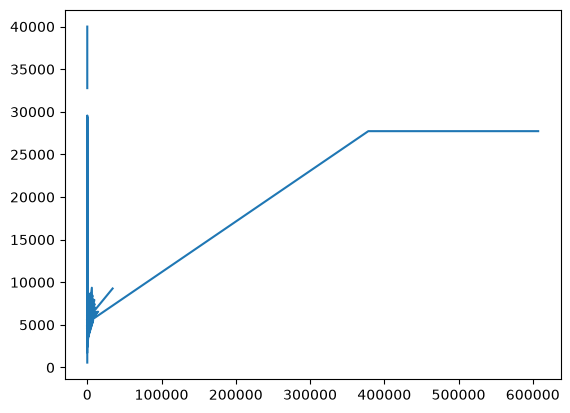

In [9]:
# Plot the data
plt.plot(nea_df['S_eff'], nea_df['st_teff'])

# Show the plot
plt.show()

Well that doesn't look pretty! All of the data is connected by lines instead of being discretized points. We can plot this as a scatter plot either by telling `plt.plot()` that we want markers or by using a different function, `plt.scatter()`.

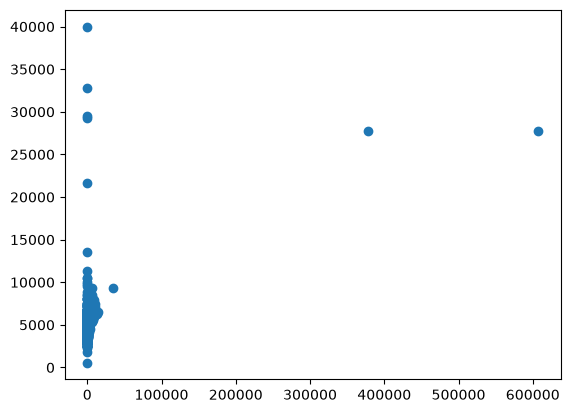

In [10]:
# The 'o' argument makes large circles
plt.plot(nea_df['S_eff'], nea_df['st_teff'], 'o')

# Show the plot
plt.show()

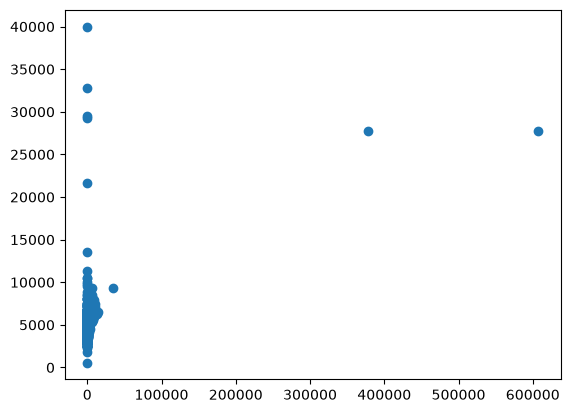

In [11]:
# Using plt.scatter
plt.scatter(nea_df['S_eff'], nea_df['st_teff'])

plt.show()

`Matplotlib`'s default color scheme isn't very appealing, and you may instead want your data to be black. Most functions within `Matplotlib` allow the `c=''` argument to change the color (alias for `color=''`). You can also adjust the type of marker you are using `marker=''`, which is useful for when you are displaying different types of data on the same axes. A complete list of markers can be found at https://matplotlib.org/stable/api/markers_api.html

We also need units on this plot! Others who look at your figures will not know what you are plotting unless you give them labels. We can add axis labels or even a title, although often in published worked plots don't have titles due to the existance of captions. `plt.xlabel()` and `plt.ylabel()` will do the trick! A cool feature of `Matplotlib` is your plots can includ LaTeX by using the usual LaTeX notation of `$Equation$`.

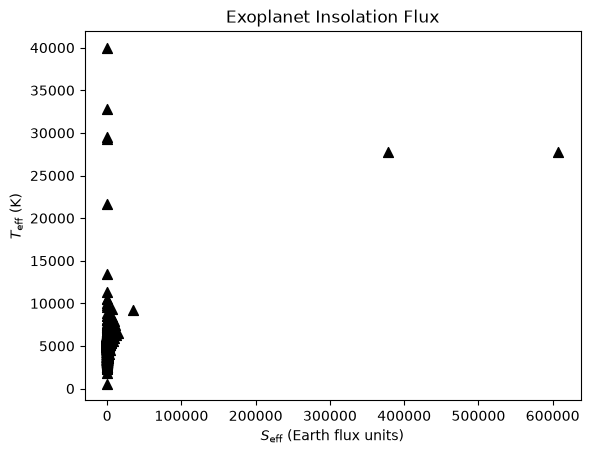

In [12]:
# Changing the color to black (k), the size to 50, and the marker to a triangle (^)
plt.scatter(nea_df['S_eff'], nea_df['st_teff'], c='k', marker='^', s=50)

# Note the dollar signs for LaTeX math mode
plt.xlabel(r'$S_{\rm eff}$ (Earth flux units)')
plt.ylabel(r'$T_{\rm eff}$ (K)')
plt.title('Exoplanet Insolation Flux')
plt.show()

These axis are way too wide! We don't really care about the extremes of the data, so we can zoom in on the region of interest by using `plt.xlim()` and `plt.ylim()`. These functions take two values, the minimum and maximum of the axis range you want to display.

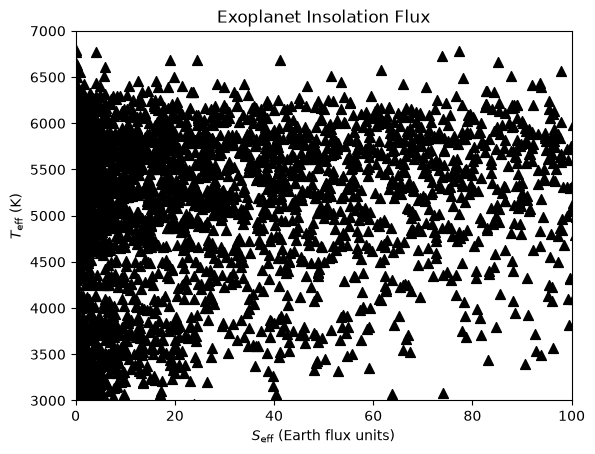

In [13]:
plt.scatter(nea_df['S_eff'], nea_df['st_teff'], c='k', marker='^', s=50)

# Note the dollar signs for LaTeX math mode
plt.xlabel(r'$S_{\rm eff}$ (Earth flux units)')
plt.ylabel(r'$T_{\rm eff}$ (K)')
plt.title('Exoplanet Insolation Flux')

# Put the limits here
plt.xlim(0, 100) # Only show planets with insolation fluxes between 0 and 100 Earth flux units
plt.ylim(3000, 7000) # Only show stars with effective temperatures between 3000 and 7000 K

plt.show()

Both of these axes have a linear scaling by default. To change the scaling of an axis, use the `xscale()` function. 

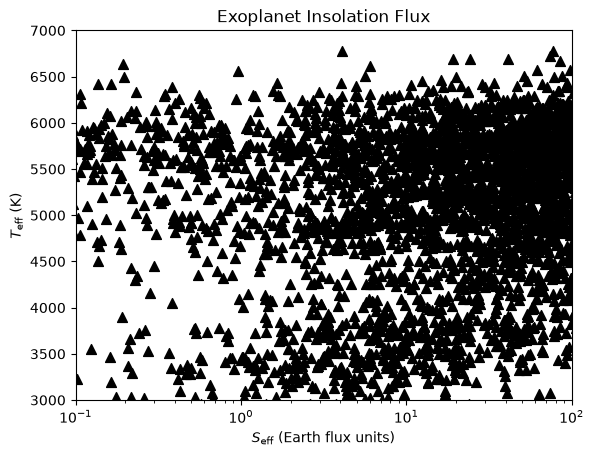

In [14]:
plt.scatter(nea_df['S_eff'], nea_df['st_teff'], c='k', marker='^', s=50)

# Note the dollar signs for LaTeX math mode
plt.xlabel(r'$S_{\rm eff}$ (Earth flux units)')
plt.ylabel(r'$T_{\rm eff}$ (K)')
plt.title('Exoplanet Insolation Flux')

# Put the limits here
plt.xscale('log') # Use a logarithmic scale for the x-axis
plt.yscale('linear') # Use a linear scale for the y-axis (done by default, but we can specify it anyway)

# The xlim/ylim function will set the limits of the figure in the order that you give them. 
# This means that you can reverse the order of the limits if you want to flip the axes.
plt.xlim(0.1, 100)
plt.ylim(3000, 7000) 

plt.show()

This is still pretty ugly... Another thing we can do is color each point individually based on another data set. 

Let's color each planet based on amount of flux it recieves. 

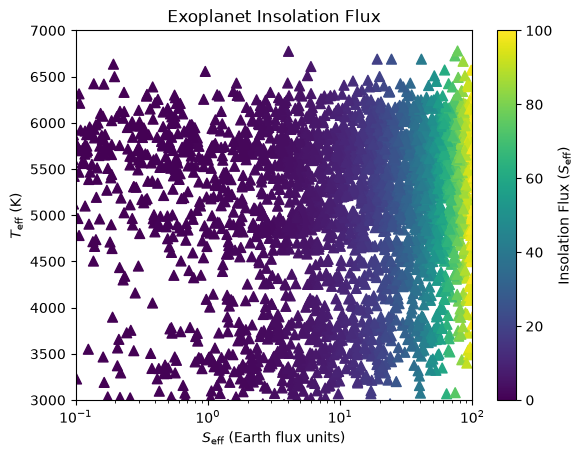

In [ ]:
plt.scatter(nea_df['S_eff'], nea_df['st_teff'], c=nea_df['S_eff'], cmap='viridis', #viridis is the name of the colormap
            s=50, marker='^', vmin=0, vmax=100) # vmin and vmax set the min and max values for the colormap

# Note the dollar signs for LaTeX math mode
plt.xlabel(r'$S_{\rm eff}$ (Earth flux units)')
plt.ylabel(r'$T_{\rm eff}$ (K)')
plt.title('Exoplanet Insolation Flux')


plt.xscale('log') 
plt.yscale('linear')

# Add a colorbar to the plot
plt.colorbar(label=r'Insolation Flux ($S_{\rm eff}$)') 

plt.xlim(0.1, 100)
plt.ylim(3000, 7000) 

plt.show()

Let's say we wanted to plot multiple different datasets on the same figure. We can use a legend to differentiate them. 

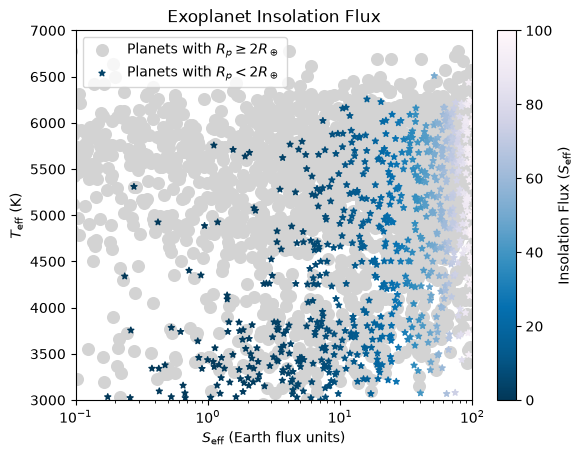

In [65]:
# This plots the planets with radii >= 2 Earth radii as larger, light gray points
plt.scatter(nea_df[nea_df['pl_rade']>= 2]['S_eff'], nea_df[nea_df['pl_rade']>= 2]['st_teff'], 
            c='lightgray', s=70, marker='o', 
            label = r'Planets with $R_p \geq 2 R_\oplus$') # label is used to label the points in the legend

# This plots the planets with radii < 2 Earth radii as smaller points colored by their insolation flux
plt.scatter(nea_df[nea_df['pl_rade']< 2]['S_eff'], nea_df[nea_df['pl_rade']< 2]['st_teff'], 
            c=nea_df[nea_df['pl_rade']< 2]['S_eff'], cmap='PuBu_r', # add _r to the colormap name to reverse the colors
            s=20, marker='*', vmin=0, vmax=100, 
            label = r'Planets with $R_p < 2 R_\oplus$')

#Add a legend to the plot
plt.legend()

# Note the dollar signs for LaTeX math mode
plt.xlabel(r'$S_{\rm eff}$ (Earth flux units)')
plt.ylabel(r'$T_{\rm eff}$ (K)')
plt.title('Exoplanet Insolation Flux')
plt.xscale('log') 
plt.yscale('linear')
plt.colorbar(label=r'Insolation Flux ($S_{\rm eff}$)') 
plt.xlim(0.1, 100)
plt.ylim(3000, 7000) 

plt.show()

We can also specific the size and resolution of our plot.

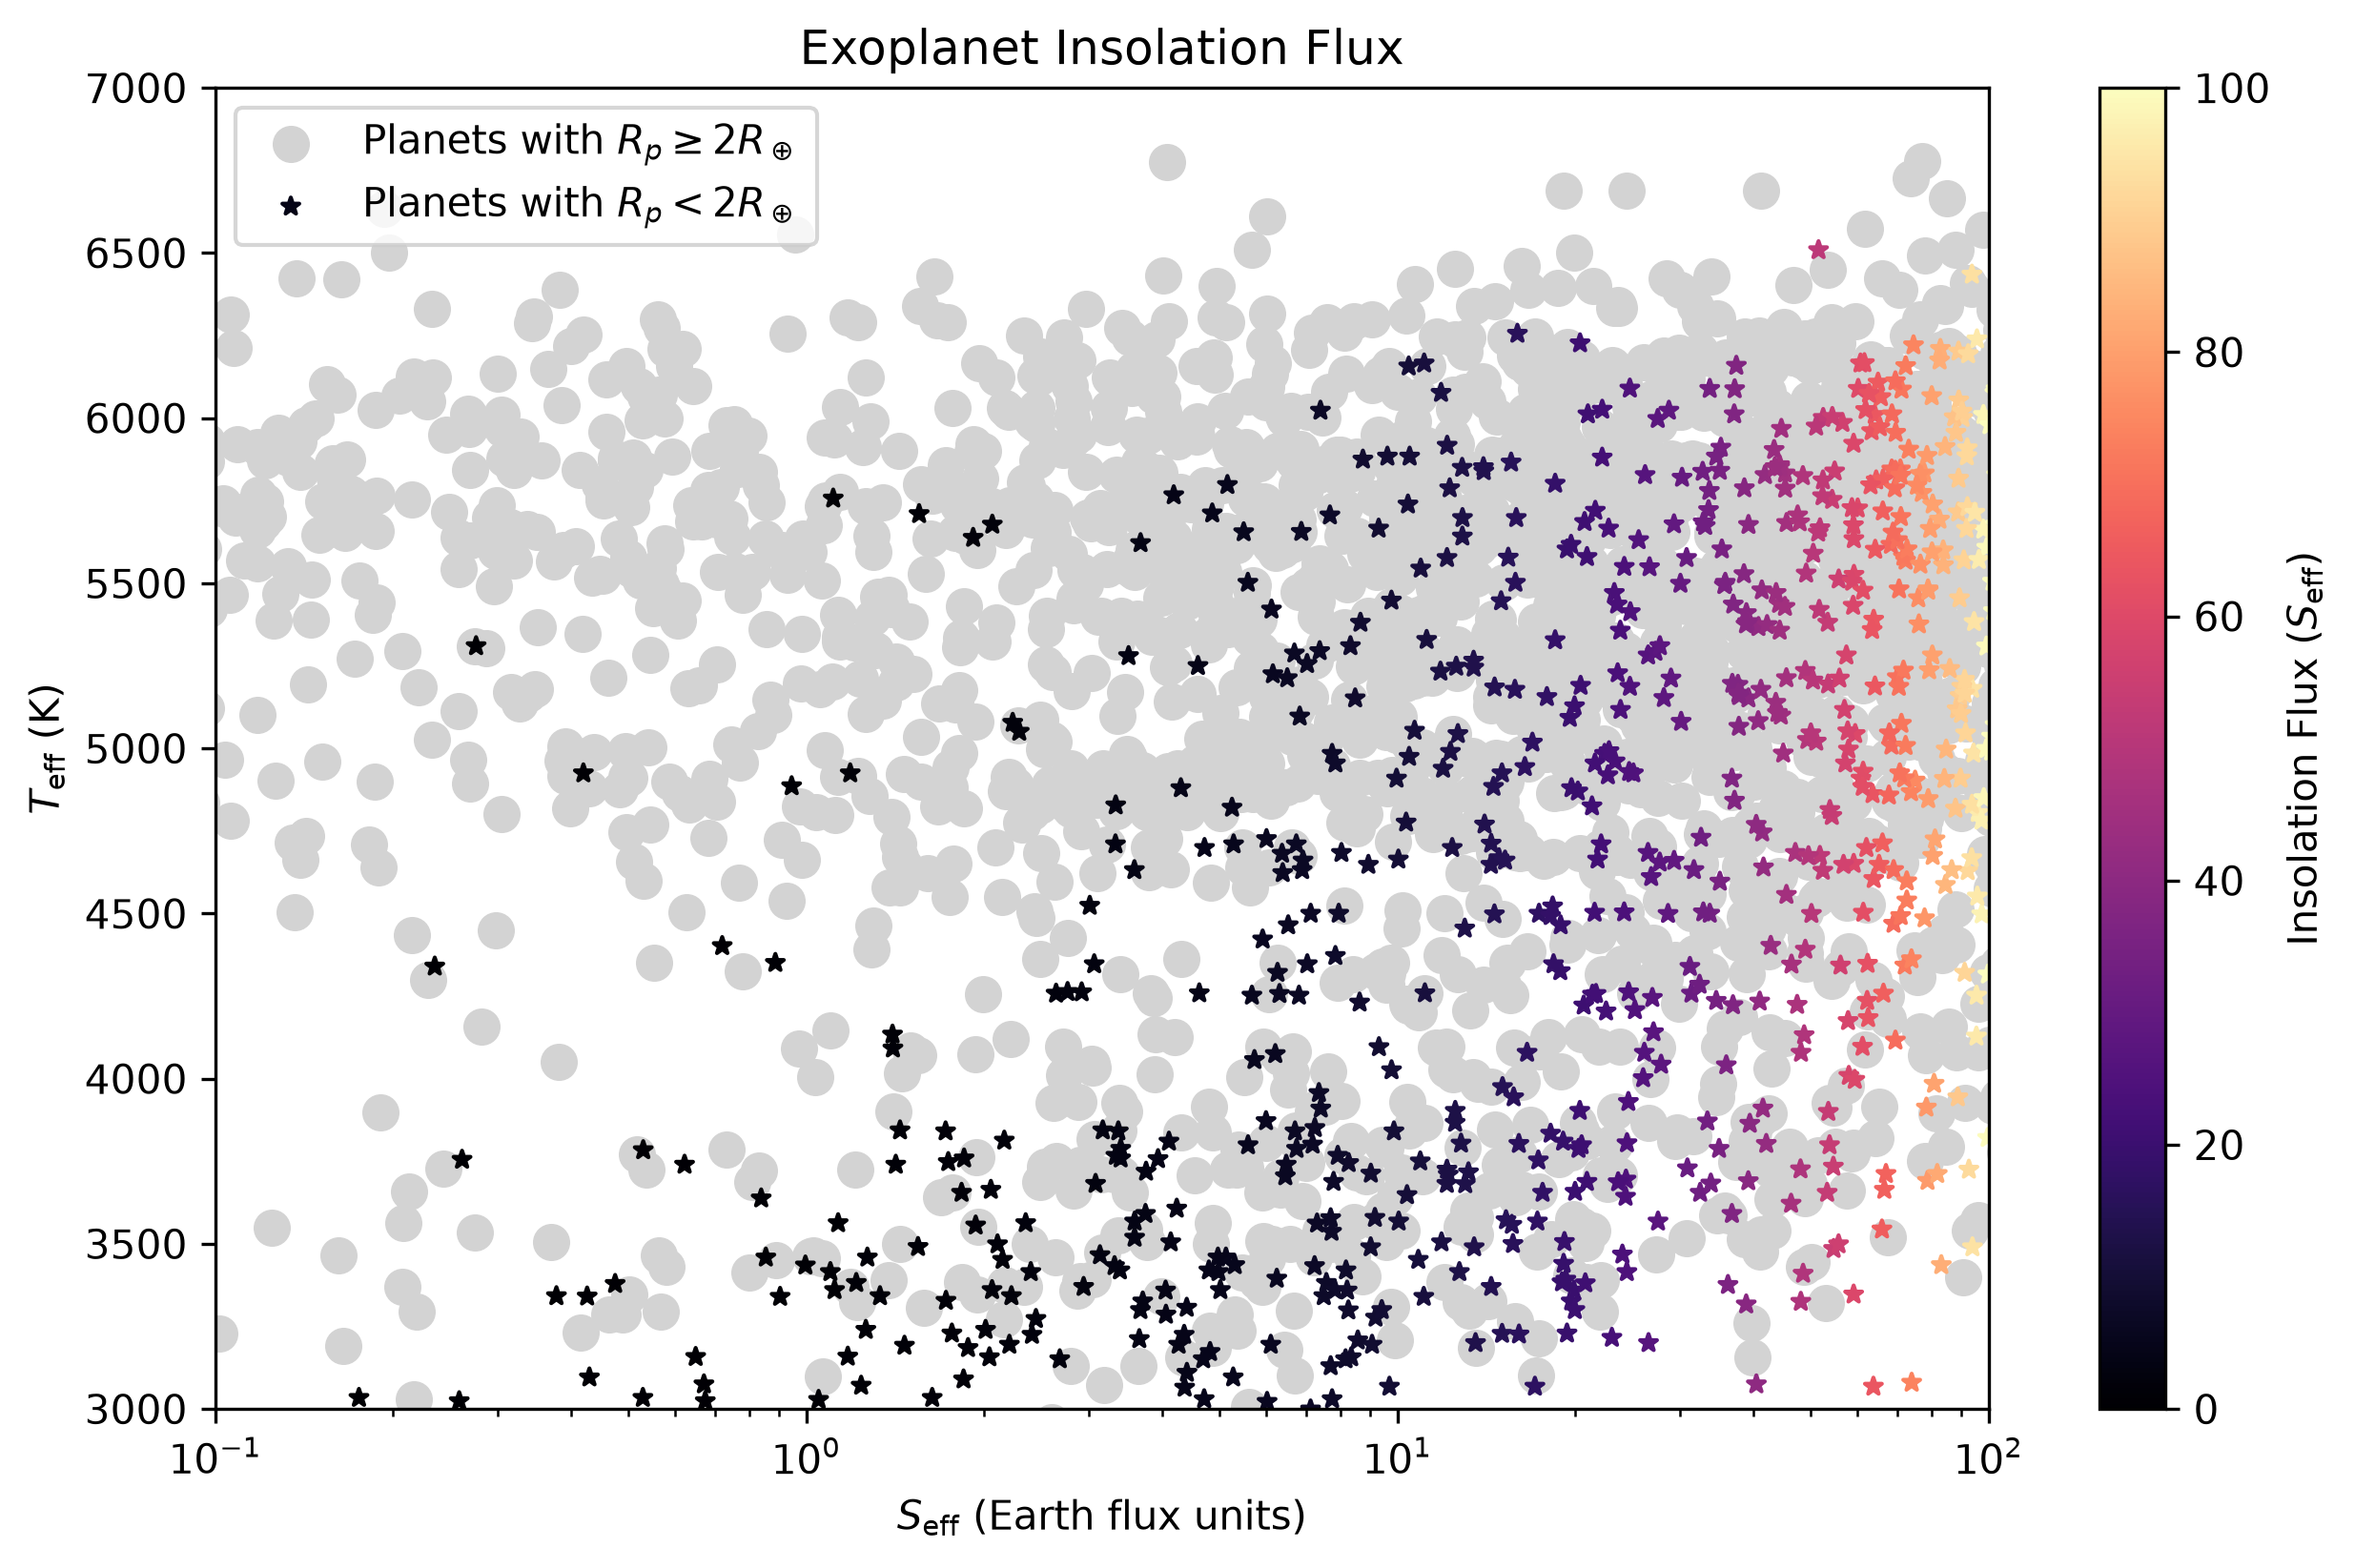

In [67]:
# Let's specify the size and resolution of our figure
plt.figure(figsize=(10, 6), dpi=300) # figsize is in inches, dpi is dots per inch

# This plots the planets with radii >= 2 Earth radii as larger, light gray points
plt.scatter(nea_df[nea_df['pl_rade']>= 2]['S_eff'], nea_df[nea_df['pl_rade']>= 2]['st_teff'], 
            c='lightgray', s=70, marker='o', 
            label = r'Planets with $R_p \geq 2 R_\oplus$') # label is used to label the points in the legend

# This plots the planets with radii < 2 Earth radii as smaller points colored by their insolation flux
plt.scatter(nea_df[nea_df['pl_rade']< 2]['S_eff'], nea_df[nea_df['pl_rade']< 2]['st_teff'], 
            c=nea_df[nea_df['pl_rade']< 2]['S_eff'], cmap='magma', 
            s=20, marker='*', vmin=0, vmax=100, 
            label = r'Planets with $R_p < 2 R_\oplus$')

#Add a legend to the plot
plt.legend()

# Note the dollar signs for LaTeX math mode
plt.xlabel(r'$S_{\rm eff}$ (Earth flux units)')
plt.ylabel(r'$T_{\rm eff}$ (K)')
plt.title('Exoplanet Insolation Flux')
plt.xscale('log') 
plt.yscale('linear')
plt.colorbar(label=r'Insolation Flux ($S_{\rm eff}$)') 
plt.xlim(0.1, 100)
plt.ylim(3000, 7000) 

plt.show()

### Numpy

Where Pandas `DataFrames` are akin to fancy dictionaries, Numpy organizes data in `ndarray`s, which are basically fancy and improved `list`s. 

We won't spend too much time going into `numpy` beyond what is immediately relevant for this class, but it is the backbone of scientific computing in Python as it makes manipulating and reshaping data much easier. 

In [16]:
# Importing the package numpy and giving it the alias np
# This is a common convention and allows us to refer to numpy functions as np.function_name
import numpy as np 

# This is a simple list of numbers in native Python
test_list = [1, 2, 3, 4, 5]

# Let's print the list and its type to see what they look like
print(test_list)
print(type(test_list))

# This is how to convert a list to a numpy array
test_array = np.array(test_list)

# Let's print the array and its type to see what they look like
print(test_array)
print(type(test_array))

# This is how to convert an array back to a list
test_list2 = test_array.tolist()

print(test_list2)
print(type(test_list2))

[1, 2, 3, 4, 5]
<class 'list'>
[1 2 3 4 5]
<class 'numpy.ndarray'>
[1, 2, 3, 4, 5]
<class 'list'>


Ok sure, but why is an `ndarray` more useful than a `list`? Well, for one, if you would like to perform operations on a group of numbers, it is way more direct and intuitive to do so through `ndarray`s than `list`s. 

In [17]:
# Let's do some simple math with the list and array. 

# We will divide each element by 2. 
halved_test_list = [x/2 for x in test_list]
print(halved_test_list)

# Gross. Now let's do the same thing with the numpy array.
halved_test_array = test_array / 2
print(halved_test_array)

[0.5, 1.0, 1.5, 2.0, 2.5]
[0.5 1.  1.5 2.  2.5]


Much cleaner! `numpy` allows us to perform operations on entire arrays at once, without needing to loop through each element.

Another useful (and directly relevant to this class) feature of `numpy` is that it allows you to generate simple arrays without having to type everything out. 

[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100.]
[  1.           1.04761575   1.09749877   1.149757     1.20450354
   1.26185688   1.32194115   1.38488637   1.45082878   1.51991108
   1.59228279   1.66810054   1.7475284    1.83073828   1.91791026
   2.009233     2.10490414   2.20513074   2.3101297    2.42012826
   2.53536449   2.65608778   2.7825594    2.91505306   3.05385551
   3.19926714   3.35160265   3.51119173   3.67837977   3.85352859
   4.03701726   4.22924287   4.43062146   4.64158883   4.86260158
   5.09413801   5.33669923   

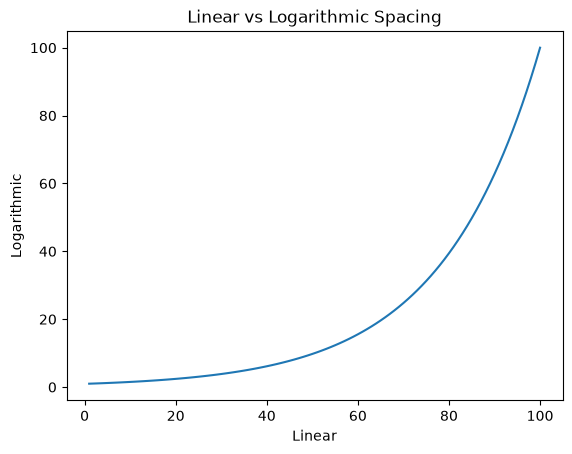

In [18]:
# Create a numpy array with 100 evenly spaced values from 1 to 100
test_arr_linear = np.linspace(1, 100, 100) 
print(test_arr_linear)

# Create a numpy array with 100 logarithmically spaced values from 10^0 to 10^2
test_arr_log = np.logspace(0, 2, 100)
print(test_arr_log)

# For fun, let's see what these look like on a plot. 
# We'll plot the linear array on the x-axis and the logarithmic array on the y-axis.
plt.plot(test_arr_linear, test_arr_log)
plt.title('Linear vs Logarithmic Spacing')
plt.xlabel('Linear')
plt.ylabel('Logarithmic')
plt.show()


Nice! There is a lot more to be said about `numpy`, but these are some basics that we will be using in this class.

### Astropy

### Units and Constants

One of the most useful features of `astropy` is its ability to handle units (the module is named `units`). If you assign a variable a unit, you can ask `astropy` to convert it do a different standard or do calculations without having to convert things yourself. Don't tell my professors, but I haven't calculated unit conversions by hand in ages thanks to `astropy`. This module alone made using Python my go-to calculator, especially since they work with `numpy` functions!

Another module, which goes hand-in-hand with `astropy.units` is `astropy.constants`. Astropy has a lot of standard constants set, such as Boltzman's constant or Plank's constant.

There is a slight learning curve with using `astropy.units`, as you need to know how they define all of the units. Most, however, are very intuitive and you can always check the docs if you're confused!

In [19]:
# Usually people load astropy modules in seperately, rather than the entire package
import astropy.units as u
import astropy.constants as c # a common alias for this is 'const', I'm just lazy

# Create a unit of length
length = 26.2 * u.m

print(length)

print(length.to(u.cm))

26.2 m
2620.0 cm


Notice above how we used the `.to()` attribute to change the units. This is incredibly useful when you need to do math and work out units!

In [20]:
# Get the recieved flux from a star
lum = 0.85 * u.Lsun
dist = 10 * u.pc

# F = L / (4 * pi * d^2)
flux = lum / (4 * np.pi * dist**2)
print(f"Flux: {flux.to(u.W / u.m**2):0.2e}")

Flux: 2.72e-10 W / m2


You might be wondering what I did to the string above. That is called "formatting" (denoted by `:`), which just alters the way the value is displayed. In this case, I asked to go to 2 decimal places (the `0.2`) and be put in scientific notation (the `e`).

Let's also use some constants to get the force of gravity between the Earth and Sun!

In [21]:
# Using constant c.G
Fg = c.G * c.M_earth * c.M_sun / c.au**2

print(f"{Fg.to(u.N):0.2e}")

3.54e+22 N


# TODO: should we add anything else here? (e.g. coordinates are so beautiful and useful but they would have to get a new additional file up and running)

All of these packages are extremely useful for data science in Python and there is a lot of functionality that we do not have time to cover. 

If you are interested in learning more about any of these packages, Aiden's Python Bootcamp (linked here: https://github.com/Shockblack/Python_Bootcamp) is a great beginner-friendly resource that goes into more depth than we do here. 

## 3. 